**Build an RNN based model (LSTM, GRU)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas import DataFrame, concat
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

**improved code**

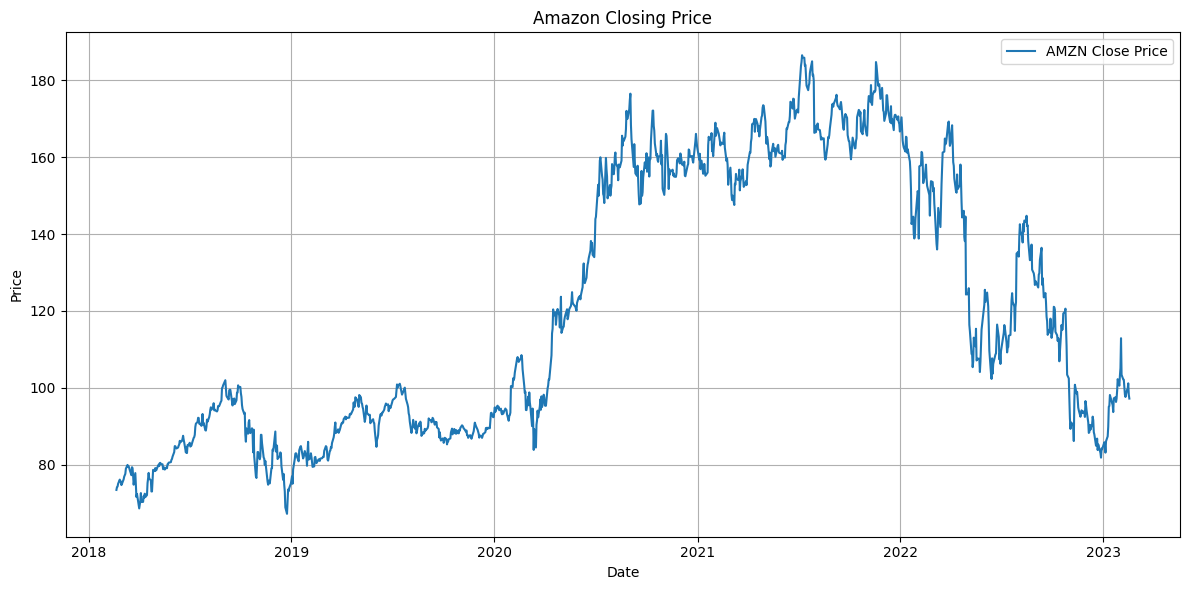

<ipython-input-2-d714941d5078>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Close'] = scaler.fit_transform(data[['Close']])


In [2]:
# Load and Visualize the Data
df = pd.read_csv("AMZN.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
data = df[['Close']]

plt.figure(figsize=(12, 6))
plt.plot(data, label='AMZN Close Price')
plt.title('Amazon Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
# Normalize for LSTM/GRU
scaler = MinMaxScaler()
data['Close'] = scaler.fit_transform(data[['Close']])

# ⛓ Sequence Creation
def create_sequences(data, seq_length):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(x), np.array(y)

seq_len = 60
X, y = create_sequences(data['Close'].values, seq_len)
X = X.reshape((X.shape[0], X.shape[1], 1))

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.1438 - val_loss: 0.0071
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0037 - val_loss: 0.0050
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0018 - val_loss: 0.0046
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0015 - val_loss: 0.0039
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0014 - val_loss: 0.0039
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0014 - val_loss: 0.0036
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0011 - val_loss: 0.0034
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0012 - val_loss: 0.0027
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0011 - val_loss: 0.0025
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 9.4004e-04 - val_loss: 0.0024
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 9.7757e-04 - val_loss: 0.0025
Epoch 12/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0011

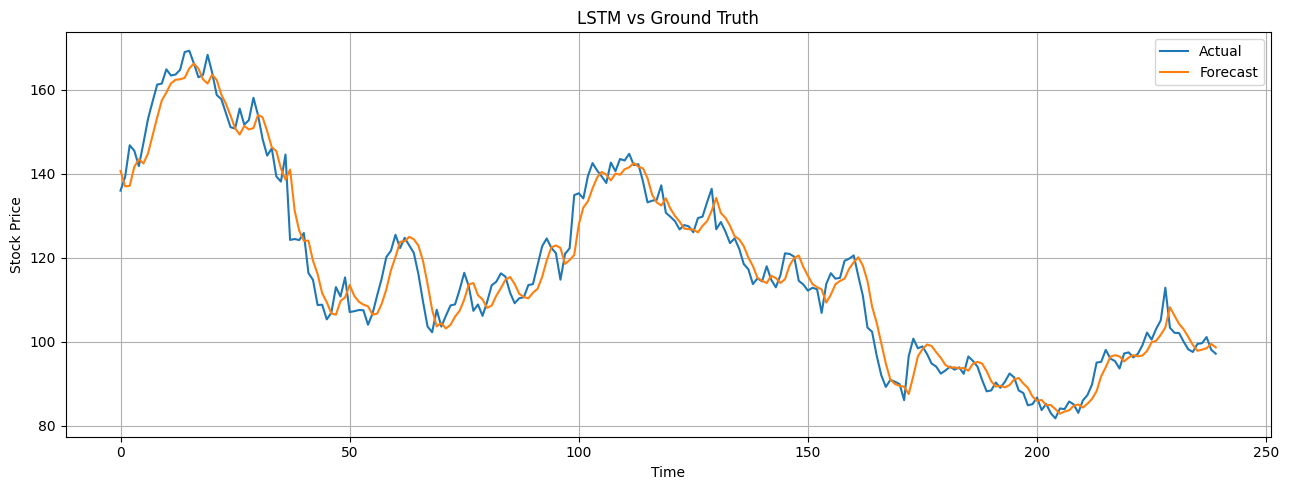

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
LSTM Model Evaluation:
MAE : 3.3319
RMSE: 4.2506
MAPE: 2.87 %


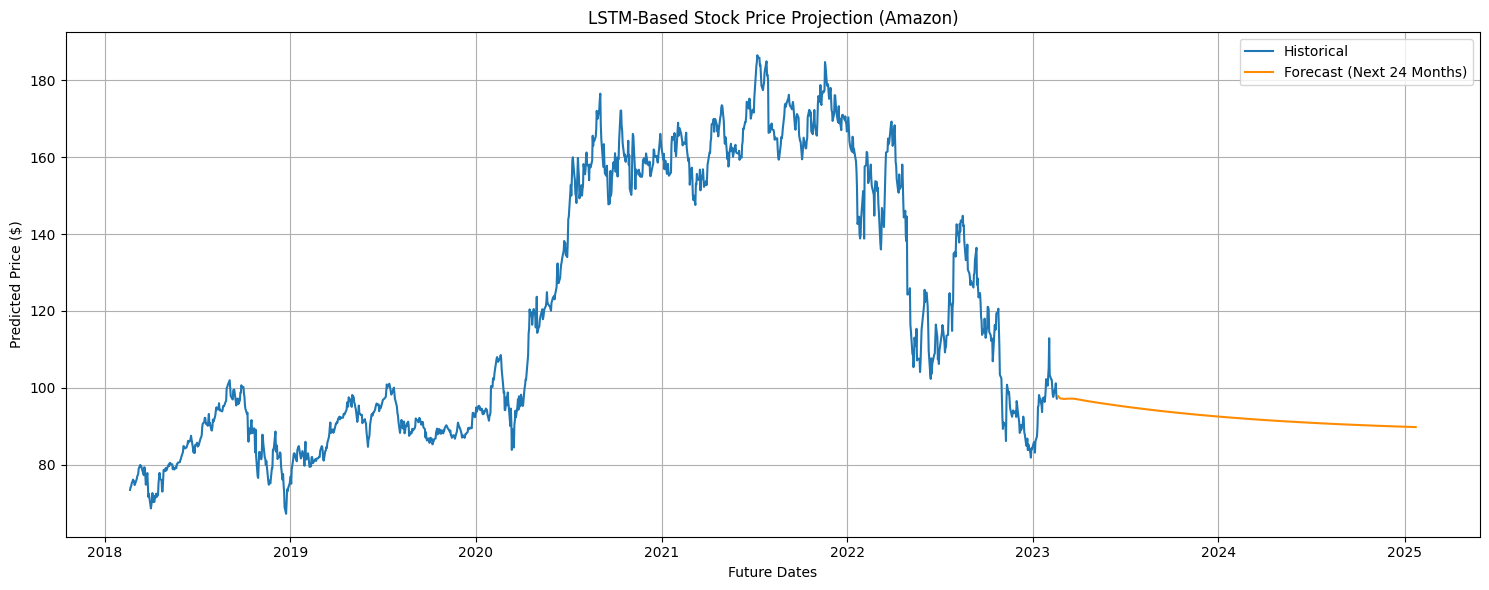

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from keras.models import Sequential
from keras.layers import LSTM, Dense
from keras.callbacks import EarlyStopping

# Load and prepare the dataset
df = pd.read_csv("AMZN.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
price_data = df[['Close']].copy()

# Scale closing prices between 0 and 1
scaler = MinMaxScaler()
price_data['Close'] = scaler.fit_transform(price_data[['Close']])

# Create input-output sequences for supervised learning
def generate_sequences(series, sequence_length):
    X_seq, y_seq = [], []
    for i in range(len(series) - sequence_length):
        X_seq.append(series[i:i+sequence_length])
        y_seq.append(series[i+sequence_length])
    return np.array(X_seq), np.array(y_seq)

# Prepare sequence data
sequence_len = 60
X, y = generate_sequences(price_data['Close'].values, sequence_len)
X = X.reshape((X.shape[0], X.shape[1], 1))

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Build the LSTM network
model_lstm = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], 1)),
    Dense(32, activation='relu'),
    Dense(1)
])

# Compile and train the model
model_lstm.compile(optimizer='adam', loss='mean_squared_error')
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model_lstm.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# Plot actual vs predicted values
def display_predictions(model, X_sample, y_sample, title="Model Output"):
    preds = model.predict(X_sample)
    plt.figure(figsize=(13, 5))
    plt.plot(scaler.inverse_transform(y_sample.reshape(-1, 1)), label='Actual')
    plt.plot(scaler.inverse_transform(preds), label='Forecast')
    plt.title(f"{title} vs Ground Truth")
    plt.xlabel("Time")
    plt.ylabel("Stock Price")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

display_predictions(model_lstm, X_test, y_test, "LSTM")

# Evaluate model performance
pred_scaled = model_lstm.predict(X_test)
actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
predicted = scaler.inverse_transform(pred_scaled).flatten()

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = mean_absolute_percentage_error(actual, predicted)

print("LSTM Model Evaluation:")
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("MAPE:", round(mape * 100, 2), "%")


# Predict future stock prices
def forecast_future_lstm(model, last_data, steps_ahead=504, seq_length=60):
    sequence = last_data[-seq_length:].reshape(1, seq_length, 1)
    forecasts = []
    for _ in range(steps_ahead):
        next_val = model.predict(sequence, verbose=0)[0][0]
        forecasts.append(next_val)
        sequence = np.append(sequence[:, 1:, :], [[[next_val]]], axis=1)
    return scaler.inverse_transform(np.array(forecasts).reshape(-1, 1))

# Generate forecast for next 504 business days
future_predictions = forecast_future_lstm(model_lstm, price_data['Close'].values, steps_ahead=504)
future_index = pd.date_range(start=price_data.index[-1] + pd.DateOffset(days=1), periods=504, freq='B')

# Plot long-term forecast results
plt.figure(figsize=(15, 6))
plt.plot(price_data.index, scaler.inverse_transform(price_data['Close'].values.reshape(-1, 1)), label='Historical')
plt.plot(future_index, future_predictions, label='Forecast (Next 24 Months)', color='darkorange')
plt.title("LSTM-Based Stock Price Projection (Amazon)")
plt.xlabel("Future Dates")
plt.ylabel("Predicted Price ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.0746 - val_loss: 0.0033
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0034 - val_loss: 0.0018
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 7.7373e-04 - val_loss: 0.0017
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 6.6267e-04 - val_loss: 0.0017
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 6.5692e-04 - val_loss: 0.0016
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 5.9952e-04 - val_loss: 0.0015
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 6.7157e-04 - val_loss: 0.0016
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 5.8461e-04 - val_loss: 0.0015
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 6.3741e-04 - val_loss: 0.0014
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 6.2847e-04 - val_loss: 0.0014
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 5.7872e-04 - val_loss: 0.0015
Epoch 12/50
30/30 ━━━━━━━━━━━━━━━━━━━━

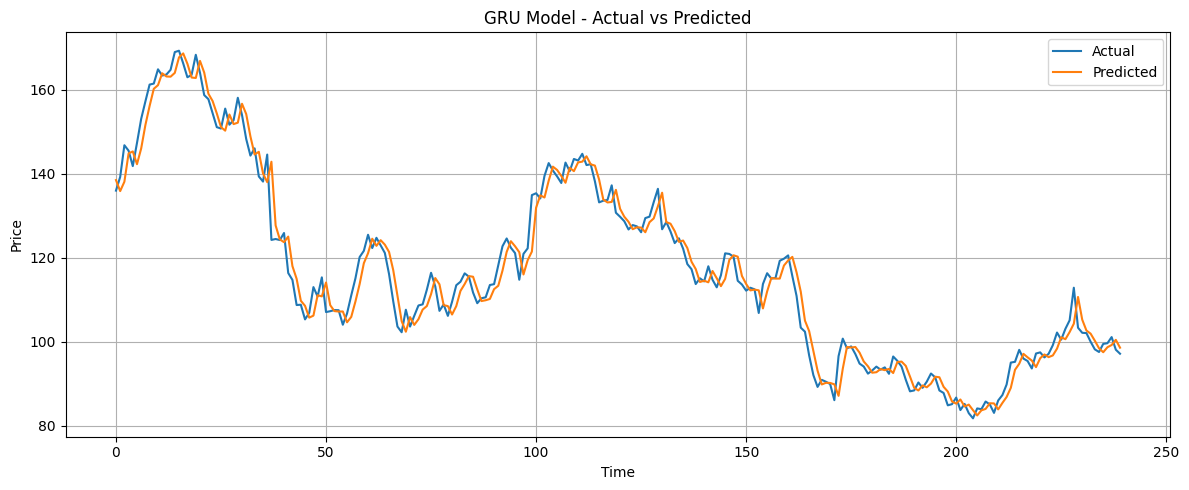

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
GRU Model Evaluation Metrics:
MAE : 2.8905
RMSE: 3.7809
MAPE: 2.49 %


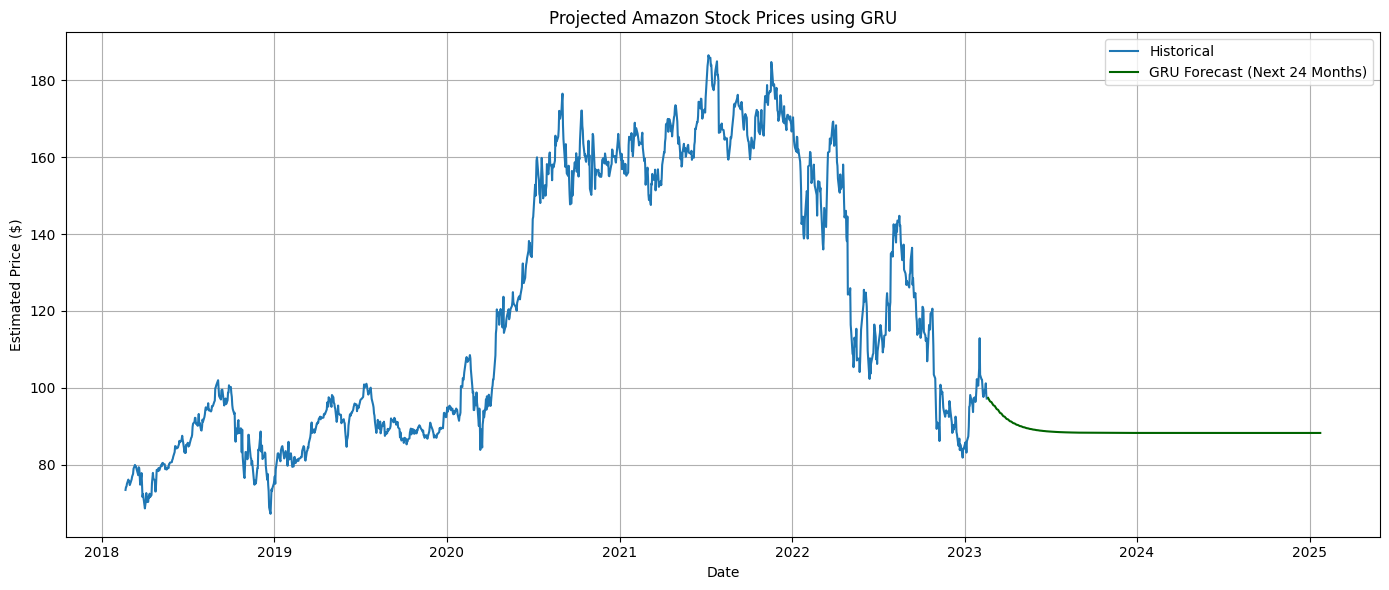

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from keras.models import Sequential
from keras.layers import GRU, Dense
from keras.callbacks import EarlyStopping

# Load Amazon stock dataset and set date as index
df = pd.read_csv("AMZN.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Extract and scale the closing prices
stock_data = df[['Close']].copy()
scaler = MinMaxScaler()
stock_data['Close'] = scaler.fit_transform(stock_data[['Close']])

# Prepare input sequences and target values
def build_sequences(series, window_size):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i:i + window_size])
        y.append(series[i + window_size])
    return np.array(X), np.array(y)

window = 60
X, y = build_sequences(stock_data['Close'].values, window)
X = X.reshape((X.shape[0], X.shape[1], 1))

# Split data for training and evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Define the GRU-based neural network
model_gru = Sequential([
    GRU(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(32, activation='relu'),
    Dense(1)
])
model_gru.compile(optimizer='adam', loss='mse')
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model on training data
model_gru.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Plot predictions against actual values
def visualize_predictions(model, X_sample, y_sample, label="GRU Model"):
    forecast = model.predict(X_sample)
    plt.figure(figsize=(12, 5))
    plt.plot(scaler.inverse_transform(y_sample.reshape(-1, 1)), label='Actual')
    plt.plot(scaler.inverse_transform(forecast), label='Predicted')
    plt.title(f"{label} - Actual vs Predicted")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

visualize_predictions(model_gru, X_test, y_test)

# Calculate performance metrics
predicted_scaled = model_gru.predict(X_test)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
predicted_prices = scaler.inverse_transform(predicted_scaled).flatten()

mae = mean_absolute_error(actual_prices, predicted_prices)
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
mape = mean_absolute_percentage_error(actual_prices, predicted_prices)

print("GRU Model Evaluation Metrics:")
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("MAPE:", round(mape * 100, 2), "%")

# Function to forecast future values using GRU
def predict_future(model, recent_data, steps=504, window_size=60):
    sequence = recent_data[-window_size:].reshape(1, window_size, 1)
    future_output = []

    for _ in range(steps):
        next_val = model.predict(sequence, verbose=0)[0][0]
        future_output.append(next_val)
        sequence = np.append(sequence[:, 1:, :], [[[next_val]]], axis=1)

    return scaler.inverse_transform(np.array(future_output).reshape(-1, 1))

# Generate forecast for 504 future business days
future_forecast = predict_future(model_gru, stock_data['Close'].values, steps=504)
forecast_dates = pd.date_range(start=stock_data.index[-1] + pd.DateOffset(days=1), periods=504, freq='B')

# Plot the extended forecast
plt.figure(figsize=(14, 6))
plt.plot(stock_data.index, scaler.inverse_transform(stock_data['Close'].values.reshape(-1, 1)), label='Historical')
plt.plot(forecast_dates, future_forecast, label='GRU Forecast (Next 24 Months)', color='darkgreen')
plt.title('Projected Amazon Stock Prices using GRU')
plt.xlabel('Date')
plt.ylabel('Estimated Price ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
